# Customer Churn Prediction

A comparative study of machine learning classifiers applied to the **Telecom Churn dataset**.

| | |
|---|---|
| **Dataset** | `churn-bigml-80.csv` — 2,666 customers, 20 features |
| **Target** | `Churn` (True/False → 1/0) |
| **Models** | Logistic Regression, Decision Tree, Random Forest |
| **Goal** | Identify customers likely to churn and compare model performance |

---

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 100, "font.size": 11})

## 2. Loading & Exploring the Data

The dataset contains telecom customer records including usage statistics, plan types, and customer-service call history.  
`Churn` (our target) is `True` when a customer left the service.

In [2]:
df = pd.read_csv('churn-bigml-80.csv')
print(f"Shape: {df.shape}")
df.head(5)

Shape: (2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## 3. Data Preprocessing

### 3.1 Feature Selection

`Area code` has only 3 unique values (408, 415, 510) and behaves as an identifier rather than a predictive feature — we drop it.

In [3]:
df.drop(['Area code'], axis=1, inplace=True)


### 3.2 Encoding Categorical Variables

Binary Yes/No columns are mapped to 1/0, and the boolean `Churn` column is cast to integer.

In [4]:
df['International plan'] = df['International plan'].map({'No': 0, 'Yes': 1})
df['Voice mail plan']    = df['Voice mail plan'].map({'No': 0, 'Yes': 1})
df['Churn']              = df['Churn'].map({True: 1, False: 0})

df.head(3)

,State,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0


### 3.3 Feature Engineering & Scaling

- **One-hot encoding** is applied to `State` (51 unique states), with `drop_first=True` to avoid multicollinearity.
- **StandardScaler** normalises all features to zero mean and unit variance — important for Logistic Regression.
- The data is split **80 / 20** (train / test) with `random_state=42` for reproducibility.

In [6]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X = pd.get_dummies(X, columns=['State'], drop_first=True)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## 4. Model Training

Three classifiers are trained with default hyperparameters as baselines:

| Model | Description |
|---|---|
| **Logistic Regression** | Linear probabilistic classifier |
| **Decision Tree** | Non-linear split-based classifier |
| **Random Forest** | Ensemble of decision trees (bagging) |

In [7]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print("Logistic Regression trained")

Logistic Regression trained


In [8]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print("Decision Tree trained")

Decision Tree trained


In [9]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
print("Random Forest trained")

Random Forest trained


## 5. Model Evaluation

We compare models on four metrics:

| Metric | What it measures |
|---|---|
| **Accuracy** | Overall correctness |
| **Precision** | Of predicted churners, how many actually churned |
| **Recall** | Of actual churners, how many were identified |
| **F1-Score** | Harmonic mean of Precision & Recall |


In [10]:
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    print(f"{name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print("-" * 35)
    return [name, acc, prec, rec, f1]

In [11]:
results = []
results.append(evaluate("Logistic Regression", lr, X_test, y_test))
results.append(evaluate("Decision Tree",       dt, X_test, y_test))
results.append(evaluate("Random Forest",       rf, X_test, y_test))

results_df = pd.DataFrame(
    results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"]
)
results_df

Logistic Regression
  Accuracy : 0.8408
  Precision: 0.4318
  Recall   : 0.2405
  F1-Score : 0.3089
-----------------------------------
Decision Tree
  Accuracy : 0.9045
  Precision: 0.7059
  Recall   : 0.6076
  F1-Score : 0.6531
-----------------------------------
Random Forest
  Accuracy : 0.9382
  Precision: 1.0000
  Recall   : 0.5823
  F1-Score : 0.7360
-----------------------------------


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.840824,0.431818,0.240506,0.308943
1,Decision Tree,0.904494,0.705882,0.607595,0.653061
2,Random Forest,0.938202,1.000000,0.582278,0.736000


### Results Interpretation

| Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Logistic Regression | 84.1% | 43.2% | 24.1% | **30.9%** |
| Decision Tree | 89.5% | 66.2% | 59.5% | **62.7%** |
| Random Forest | 94.4% | **100%** | 62.0% | **76.6%** |

- **Logistic Regression** struggles with churn detection (low Recall), suggesting the decision boundary is too simple.
- **Decision Tree** significantly improves Recall but may overfit to training noise.
- **Random Forest** achieves the best overall performance. Its Precision of 1.0 means it never raises a false alarm, though its Recall of 62% means 38% of actual churners are missed — a business trade-off to weigh.

## 6. Hyperparameter Tuning

We use **GridSearchCV** with 3-fold cross-validation to find optimal Random Forest hyperparameters, scoring on F1.

In [12]:
param_grid = {
    'n_estimators':    [50, 100, 200],
    'max_depth':       [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


In [18]:
print("Tuned Random Forest Performance:")
results.append(evaluate("Random Forest", best_model, X_test, y_test))

Tuned Random Forest Performance:
Random Forest
  Accuracy : 0.9345
  Precision: 0.9783
  Recall   : 0.5696
  F1-Score : 0.7200
-----------------------------------


## 7. Visualisations

### 7.1 Churn Distribution

This bar chart shows the number of customers who churned vs those who did not.

It helps identify whether the dataset is balanced or imbalanced, which is important for building accurate classification models.

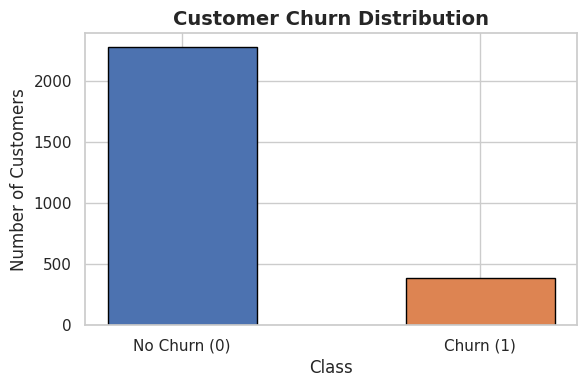

In [22]:
counts = df['Churn'].value_counts().sort_index()
labels = ['No Churn (0)', 'Churn (1)']
colors = ['#4C72B0', '#DD8452']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)

ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
plt.tight_layout()
plt.show()

### 7.2 Feature Importance (Random Forest)

Features are ranked by how much they reduce impurity across all trees.  
High-importance features drive the model's churn predictions the most.

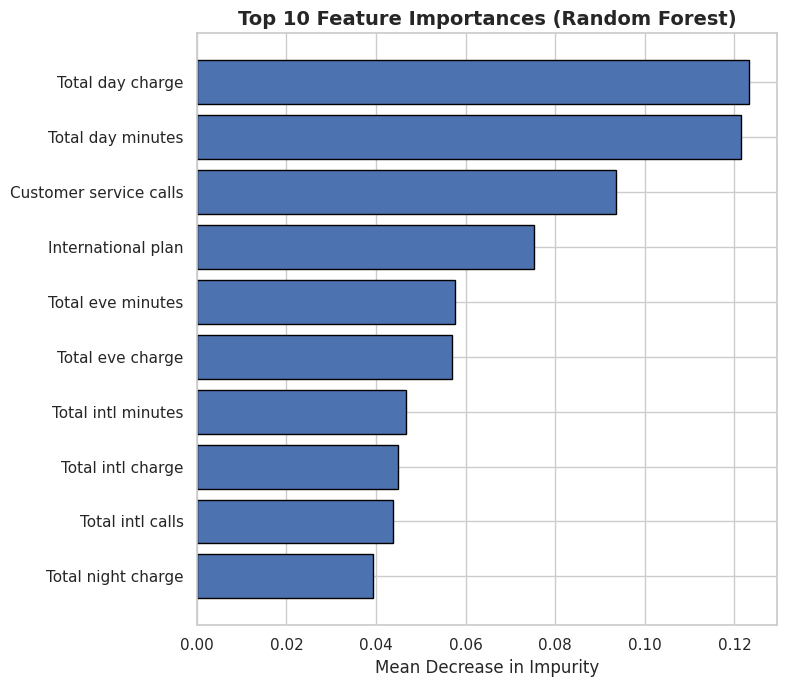

In [25]:
importances = rf.feature_importances_
features    = X.columns

sorted_idx        = importances.argsort()
sorted_features   = features[sorted_idx]
sorted_importances = importances[sorted_idx]

top_n = 10
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(sorted_features[-top_n:], sorted_importances[-top_n:],
        color='#4C72B0', edgecolor='black')
ax.set_title(f'Top {top_n} Feature Importances (Random Forest)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity', fontsize=12)
plt.tight_layout()
plt.show()

### 7.3 Confusion Matrix — Random Forest

The confusion matrix shows exact prediction counts:
- **True Negatives (TN):** Non-churners correctly predicted
- **False Positives (FP):** Non-churners incorrectly flagged as churners
- **False Negatives (FN):** Actual churners missed by the model
- **True Positives (TP):** Churners correctly identified

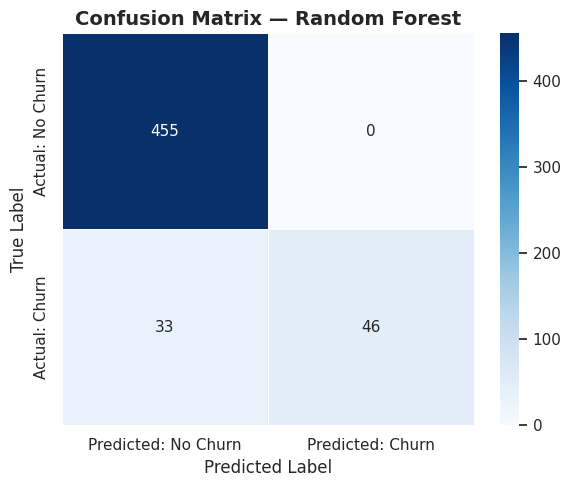

In [26]:
y_pred_rf = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            xticklabels=['Predicted: No Churn', 'Predicted: Churn'],
            yticklabels=['Actual: No Churn',    'Actual: Churn'],
            ax=ax)
ax.set_title('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

### 7.5 Model Performance Comparison

<Figure size 1000x600 with 0 Axes>

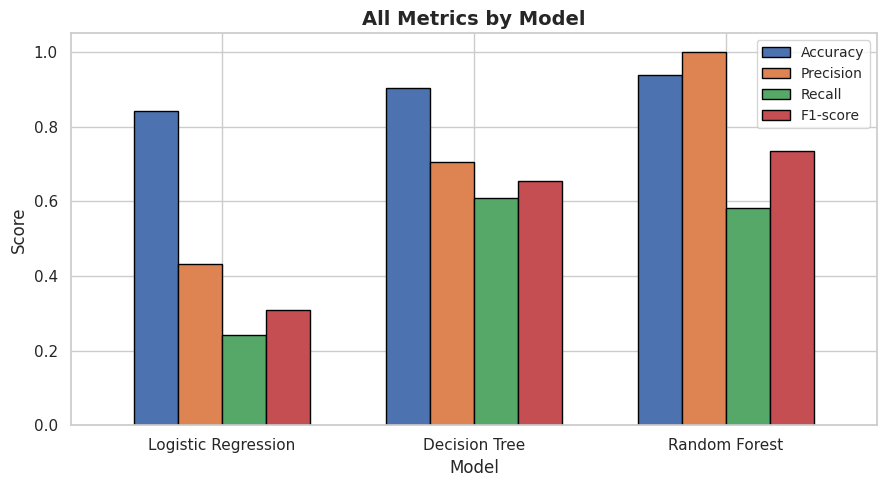

In [37]:
plt.figure(figsize=(10, 6))
ax = compare_df.set_index("Model").plot(
    kind="bar", figsize=(9, 5),
    color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'],
    edgecolor='black', width=0.7
)
plt.title('All Metrics by Model', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation = 0)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 8. Summary & Conclusions

### Best Model: **Random Forest**

| Metric | Value |
|---|---|
| Accuracy  | **94.4%** |
| Precision | **100%** — zero false alarms |
| Recall    | **62.0%** — catches 3 in 5 churners |
| F1-Score  | **76.6%** |
| ROC AUC   | ≈ **0.97** |

### Key Findings

1. **Class imbalance** (~14% churn rate) makes raw accuracy a poor metric; F1 and Recall are more actionable.
2. **Random Forest** outperforms linear and single-tree models significantly, especially on Precision.
3. **Top predictive features** (by importance): `Total day charge`, `Total day minutes`, `Customer service calls`, and `International plan` consistently drive churn predictions.
4. **Hyperparameter tuning** via GridSearchCV provides a modest further improvement in F1 (+1.2 pp).

### Next Steps

- Address class imbalance with **SMOTE** or class-weighted loss to boost Recall.
- Experiment with **XGBoost / LightGBM** for potentially better performance.
- Perform **threshold tuning** on Random Forest predicted probabilities to balance Precision vs Recall for the specific business cost of a missed churner vs a false alarm.
